In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



In [ ]:
df = pd.read_csv("data/complete.csv", usecols=range(0, 11))
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 88875 entries, 0 to 88874
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   datetime              88875 non-null  str    
 1   city                  88679 non-null  str    
 2   state                 81356 non-null  str    
 3   country               76314 non-null  str    
 4   shape                 85757 non-null  str    
 5   duration (seconds)    88873 non-null  object 
 6   duration (hours/min)  85772 non-null  str    
 7   comments              88749 non-null  str    
 8   date posted           88875 non-null  str    
 9   latitude              88875 non-null  str    
 10  longitude             88875 non-null  float64
dtypes: float64(1), object(1), str(9)
memory usage: 7.5+ MB


C:\Users\wslid\AppData\Local\Temp\ipykernel_31464\611839031.py:1: DtypeWarning: Columns (0: duration (seconds)) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("complete.csv", usecols=range(0, 11))


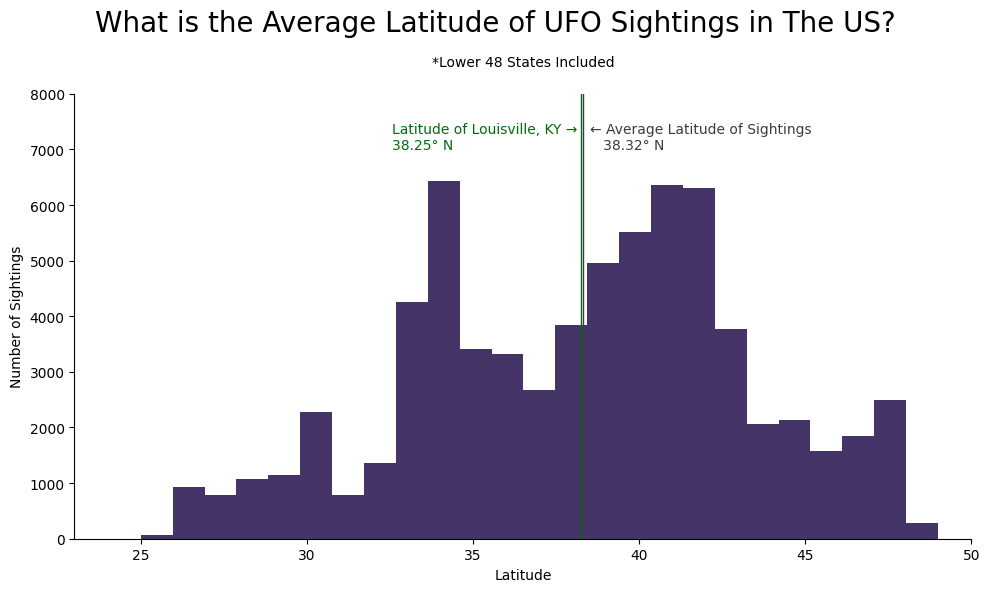

In [ ]:
# latitude cleaning 
df["latitude"] = pd.to_numeric(
    df["latitude"].astype(str).str.replace(r".*/.*", "", regex=True),
    errors="coerce"
)

# rounded_lat for lower 48 
df["rounded_lat"] = df["latitude"].where(
    (df["country"].str.lower() == "us") & 
    (df["latitude"].between(24, 50))
).round(0)

mean_latitude = df["latitude"].where(
    (df["country"].str.lower() == "us") & 
    (df["latitude"].between(24, 50))
).mean().round(2)

louisville_latitude = 38.25

plt.figure(figsize=(10,6))

# Histogram with Only non-NaN US Values
plt.hist(df['rounded_lat'].dropna(), 
         bins=25,                    
         color="#170141", 
         alpha=0.8)

plt.xlabel("Latitude")
plt.ylabel("Number of Sightings")
plt.suptitle("What is the Average Latitude of UFO Sightings in The US?", fontsize=20)
plt.title("*Lower 48 States Included", fontsize=10, pad=20)

ax = plt.gca()
ax.axvline(mean_latitude, linewidth=1, color="#3a3b45")
ax.text(mean_latitude + 0.2, 7000,
        f"← Average Latitude of Sightings\n   {mean_latitude}° N",
        color="#3a3b45")

ax.axvline(louisville_latitude, linewidth=1, color="#006c0e")
ax.text(louisville_latitude - 5.7, 7000,
        f"Latitude of Louisville, KY →\n{louisville_latitude}° N",
        color="#006c0e")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlim(23, 50)
plt.ylim(0, 8000)

plt.tight_layout()
plt.show()

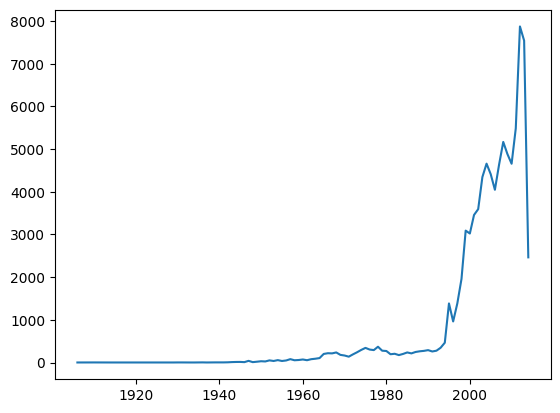

In [70]:
df['datetime'] = pd.to_datetime(df['datetime'].astype(str), errors="coerce")
df['year'] = df['datetime'].dt.year

yearly_totals = df.groupby(['year']).size()

plt.plot(yearly_totals.index, yearly_totals)
plt.show()
plt.show()

In [11]:
# Group by shape
shapes = df.groupby('shape')

# Total sightings per shape
shape_totals = shapes.size()

# Average sighting datetime per shape
shapes_avg_year = shapes['datetime'].mean()

# Combine both into one DataFrame
shapes_avg_year_totals_df = pd.concat([shapes_avg_year, shape_totals], axis=1)


shapes_avg_year_totals_df


 


,datetime,0
shape,,
changed,1996-06-24 00:30:00.000000,1
changing,2005-08-24 13:52:04.938505,2140
chevron,2003-07-22 04:21:44.475524,1007
cigar,2000-04-05 04:03:21.197278,2241
circle,2005-03-18 07:35:28.558072,8453
cone,2004-12-26 22:58:12.657534,367
crescent,1997-07-24 22:25:30.000000,2
cross,2006-06-17 10:57:22.900763,265
cylinder,2003-08-20 08:24:27.308823,1382


In [12]:
print(df['shape'].unique())

<StringArray>
[ 'cylinder',     'light',    'circle',    'sphere',      'disk',  'fireball',
   'unknown',      'oval',     'other',     'cigar', 'rectangle',   'chevron',
  'triangle', 'formation',         nan,     'delta',  'changing',       'egg',
     'flash',   'diamond',     'cross',  'teardrop',      'cone',   'pyramid',
     'round',  'crescent',     'flare',   'hexagon',      'dome',   'changed']
Length: 30, dtype: str


# Distribution of Shape Sightings Over Time

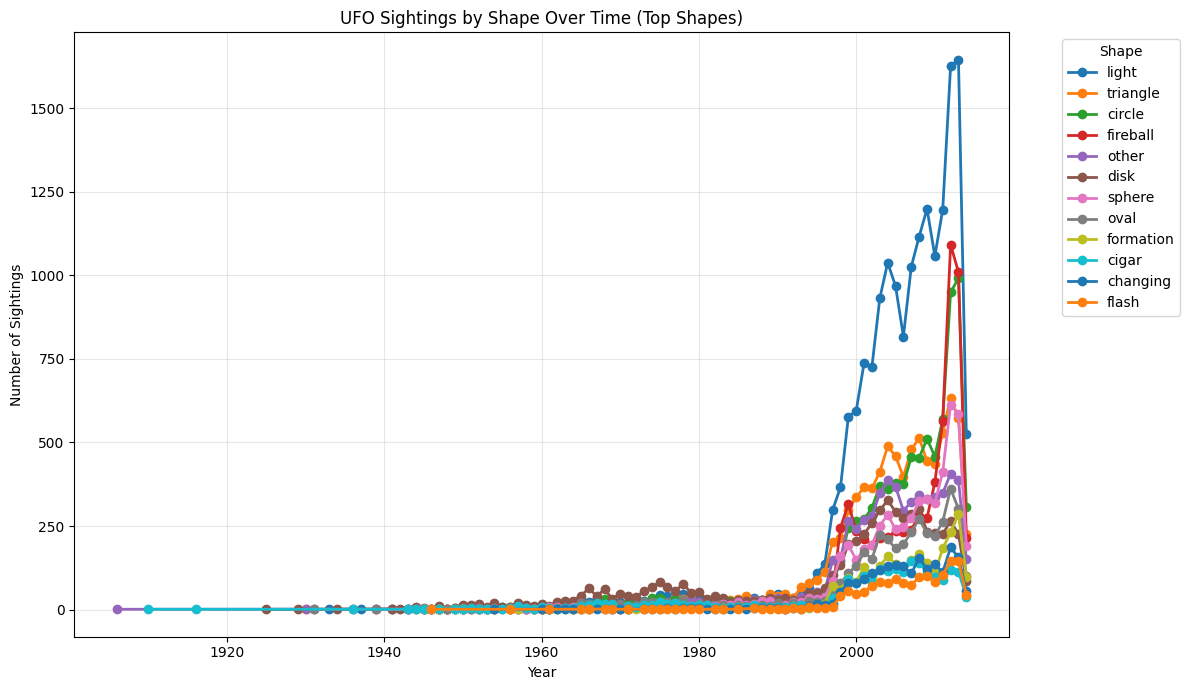

In [13]:
# Extract year
df['year'] = df['datetime'].astype(str).str[:4].astype(float)


# Count sightings per shape per year
shape_year = df.groupby(['shape', 'year']).size().reset_index(name='count')

plt.figure(figsize=(12, 7))

# Top shapes excluding 'unknown'
top_shapes = (df['shape']
              .value_counts()
              .drop('unknown', errors='ignore')   # safely drop unknown
              .head(12)
              .index)

df_top = shape_year[shape_year['shape'].isin(top_shapes)]

# Plot each shape as a separate line
for shape in top_shapes:
    data = df_top[df_top['shape'] == shape]
    plt.plot(data['year'], data['count'], 
             marker="o", 
             linestyle="-", 
             linewidth=2,
             label=shape)

plt.xlabel("Year")
plt.ylabel("Number of Sightings")
plt.title("UFO Sightings by Shape Over Time (Top Shapes)")
plt.legend(title="Shape", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

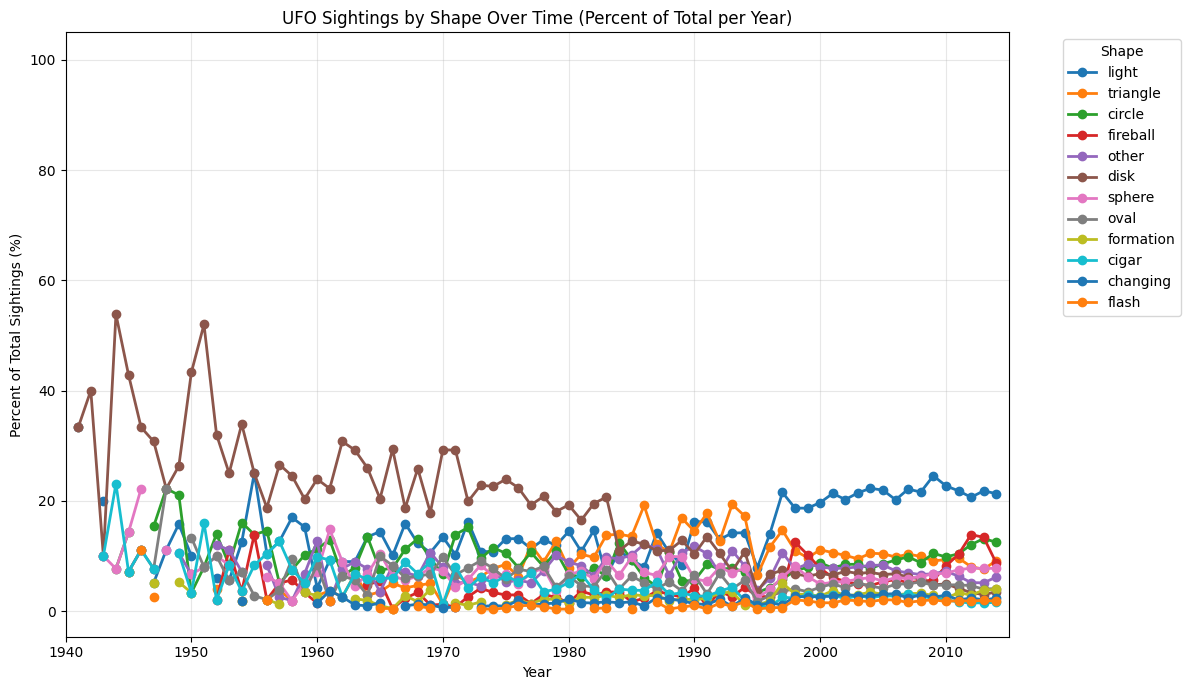

In [14]:
# Shape as a % of Sightings in Each Year
# Include Top Shapes Only

# Extract year
df['year'] = df['datetime'].astype(str).str[:4].astype(float)

# Total Sightings Per Year
year_totals = df.groupby('year').size()

# Count sightings per shape per year
shape_year = df.groupby(['shape', 'year']).size().reset_index(name='count')

plt.figure(figsize=(12, 7))

# Top shapes excluding 'unknown'
top_shapes = (df['shape']
              .value_counts()
              .drop('unknown', errors='ignore')
              .head(12)
              .index)

df_top = shape_year[shape_year['shape'].isin(top_shapes)]

# Plot each shape as a separate line (as % of total that year)
for shape in top_shapes:
    data = df_top[df_top['shape'] == shape].set_index('year')
    percent = (data['count'] / year_totals * 100)
    plt.plot(percent.index, percent.values, 
             marker="o", 
             linestyle="-", 
             linewidth=2,
             label=shape)

plt.xlabel("Year")
plt.ylabel("Percent of Total Sightings (%)")
plt.title("UFO Sightings by Shape Over Time (Percent of Total per Year)")
plt.legend(title="Shape", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

plt.xlim(1940, 2015)


plt.tight_layout()
plt.show()

# organize by type of shape 

In [15]:
# find unique shapes 

print(df['shape'].unique().dropna())

<StringArray>
[ 'cylinder',     'light',    'circle',    'sphere',      'disk',  'fireball',
   'unknown',      'oval',     'other',     'cigar', 'rectangle',   'chevron',
  'triangle', 'formation',     'delta',  'changing',       'egg',     'flash',
   'diamond',     'cross',  'teardrop',      'cone',   'pyramid',     'round',
  'crescent',     'flare',   'hexagon',      'dome',   'changed']
Length: 29, dtype: str


In [16]:
# group shapes by types 

shape_groups = {
    'circle': 'round', 'sphere': 'round', 'disk': 'round', 
    'oval': 'round', 'round': 'round', 'crescent': 'round', 'dome': 'round',
    'egg': 'round', 'teardrop': 'round',
    
    'triangle': 'triangle', 'delta': 'triangle', 'chevron': 'triangle', 
    'pyramid': 'triangle', 'diamond': 'triangle',
    
    'cylinder': 'cigar', 'cigar': 'cigar',
    
    'light': 'light', 'fireball': 'light', 'flash': 'light', 'flare': 'light',
    
    'changing': 'changing', 'changed': 'changing', 'formation': 'changing', 'cone': 'changing',
    'cross': 'changing', 'hexagon': 'changing', 'rectangle': 'changing',
    
    'other': 'other'
}

df['shape_group'] = df['shape'].map(shape_groups)

df['shape_group'].value_counts()


shape_group
round       25999
light       25907
triangle    10813
changing     6849
other        6247
cigar        3623
Name: count, dtype: int64

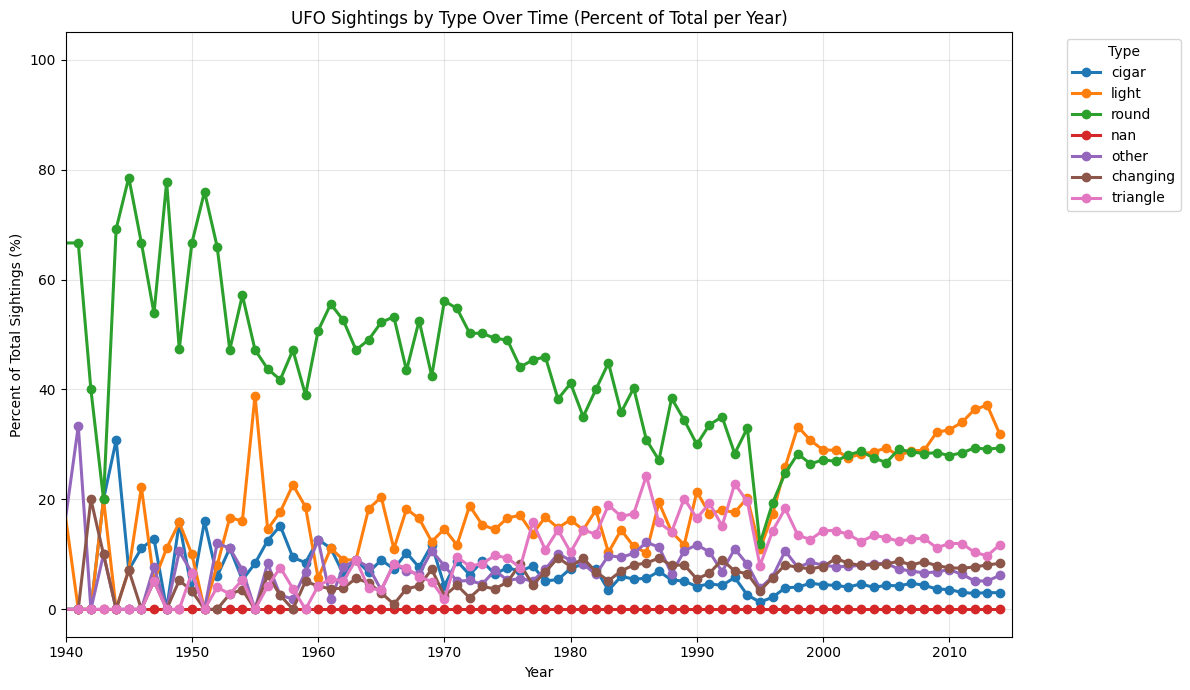

In [17]:
# Types % Share of Sightings Over Time 

# Total Sightings Per Year
year_totals = df.groupby('year').size()

# Count sightings per shape_group per year
shape_group_year = df.groupby(['shape_group', 'year']).size().reset_index(name='count')

plt.figure(figsize=(12, 7))

# Plot each shape group as a separate line (% of total that year)
for group in df['shape_group'].unique():
    data = shape_group_year[shape_group_year['shape_group'] == group].set_index('year')
    percent = (data['count'] / year_totals * 100).fillna(0)
    plt.plot(percent.index, percent.values, 
             marker="o", 
             linestyle="-", 
             linewidth=2.2,
             label=group)

plt.xlabel("Year")
plt.ylabel("Percent of Total Sightings (%)")
plt.title("UFO Sightings by Type Over Time (Percent of Total per Year)")
plt.legend(title="Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

plt.xlim(1940, 2015)
plt.tight_layout()
plt.show()

In [18]:
# Rank by State .. Population Weighted 

df_ky = df[df['state'].str.lower() == 'ky'].copy()

df_ky.describe()

,datetime,latitude,longitude,rounded_lat,year
count,983,1000.000000,1002.000000,931.000000,983.000000
mean,2003-05-27 05:59:54.445574,37.506843,-84.531369,37.773362,2002.863683
min,1943-10-15 11:00:00,0.000000,-89.186111,37.000000,1943.000000
25%,2001-03-18 03:30:00,37.138333,-85.956247,37.000000,2001.000000
50%,2007-02-16 21:51:00,37.839333,-85.252778,38.000000,2007.000000
75%,2011-06-29 11:25:00,38.254167,-84.294722,38.000000,2011.000000
max,2014-05-04 20:15:00,39.106389,0.000000,39.000000,2014.000000
std,NaN,3.217155,8.199246,0.623189,11.908157


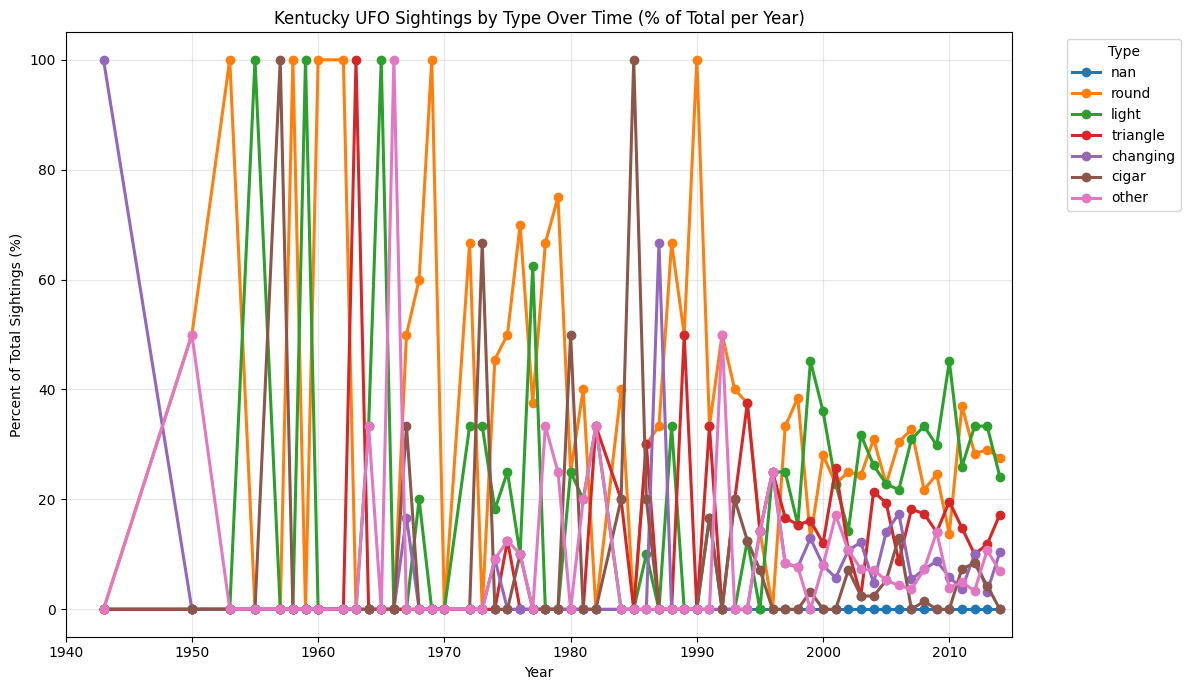

In [19]:
# Types % Share of Sightings Over Time in Kentucky

# Total Sightings Per Year in Kentucky
ky_year_totals = df_ky.groupby('year').size()

# Count sightings per shape_group per year in Kentucky
ky_shape_group_year = df_ky.groupby(['shape_group', 'year']).size().reset_index(name='count')

plt.figure(figsize=(12, 7))

# Plot each shape group as a separate line (% of total that year in KY)
for group in df_ky['shape_group'].unique():
    data = ky_shape_group_year[ky_shape_group_year['shape_group'] == group].set_index('year')
    percent = (data['count'] / ky_year_totals * 100).fillna(0)
    plt.plot(percent.index, percent.values, 
             marker="o", 
             linestyle="-", 
             linewidth=2.2,
             label=group)

plt.xlabel("Year")
plt.ylabel("Percent of Total Sightings (%)")
plt.title("Kentucky UFO Sightings by Type Over Time (% of Total per Year)")
plt.legend(title="Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

plt.xlim(1940, 2015)
plt.tight_layout()
plt.show()

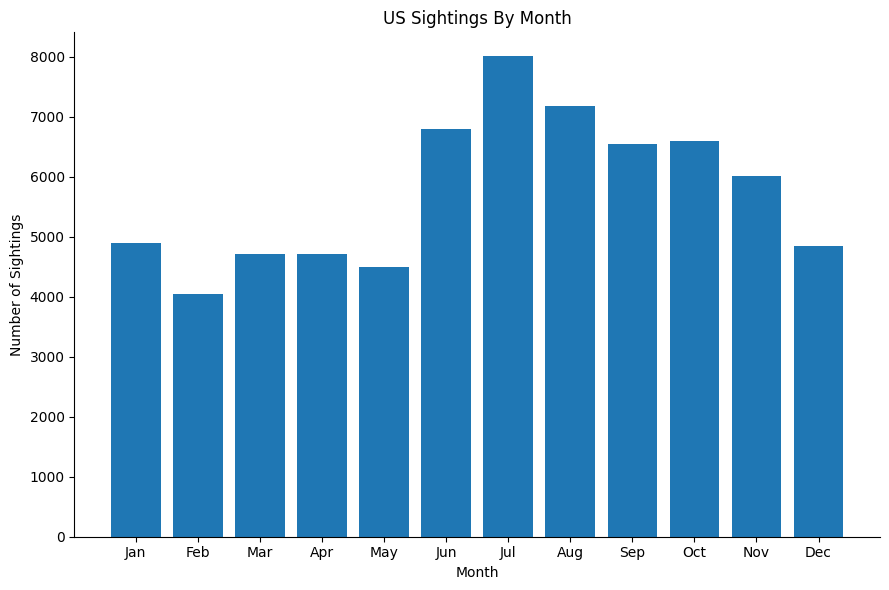

In [64]:
# get month
# histogram by month
# us sightings by month
# us sightings by season - season_group column


df['month'] = pd.to_datetime(df['datetime']).dt.month

us_df = df[
    (df['country'].str.lower() == 'us') & 
    (df['latitude'].between(24, 50))
].copy()

us_monthly = us_df['month'].value_counts().sort_index()

plt.figure(figsize=(9, 6))

plt.bar(us_monthly.index, us_monthly.values)
plt.title("US Sightings By Month")
plt.xlabel("Month")
plt.xticks(ticks=range(1,13), labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.ylabel("Number of Sightings")

ax = plt.gca()
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

plt.tight_layout()
plt.show()



